In [1]:
# Cell 1: Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
import warnings
warnings.filterwarnings('ignore')

# Enable inline plots in Jupyter
%matplotlib inline
plt.style.use('seaborn-v0_8')

# Cell 2: Generate Synthetic Data (Mimicking Your Situation)
np.random.seed(42)
months = pd.date_range('2024-06-01', periods=24, freq='M')

# Base organic sales with growth + seasonality
base_organic = 280000 + np.cumsum(np.random.normal(12000, 22000, 24))
seasonality = 35000 * np.sin(2 * np.pi * np.arange(24)/12)

# Spends - Heavy scaling on Display placements
mini_spend = np.concatenate([np.linspace(8000, 18000, 8), np.linspace(19000, 62000, 16)])
banner_spend = np.concatenate([np.linspace(3500, 9000, 8), np.linspace(10000, 85000, 16)])
search_spend = np.linspace(32000, 41000, 24)


In [8]:
# Sales response with diminishing returns
def sales_response(spend, base_roas, saturation=0.0001):
    return base_roas * spend * (1 - np.exp(-saturation * spend))

mini_contrib = sales_response(mini_spend, base_roas=11, saturation=0.00013)
banner_contrib = sales_response(banner_spend, base_roas=7, saturation=0.000045)   # Stronger saturation
search_contrib = sales_response(search_spend, base_roas=5, saturation=0.00009)

total_sales = (base_organic + seasonality +
               mini_contrib + banner_contrib + search_contrib +
               np.random.normal(0, 25000, 24))

df = pd.DataFrame({
    'Month': months.strftime('%Y-%m'),
    'Total_RSV_Sales': total_sales.astype(int),
    'Mini_Spend': mini_spend.astype(int),
    'Banner_Spend': banner_spend.astype(int),
    'Search_Spend': search_spend.astype(int)
})

print("=== Data Summary ===")
print(df.describe())
df.head()

=== Data Summary ===
       Total_RSV_Sales   Mini_Spend  Banner_Spend  Search_Spend
count     2.400000e+01     24.00000     24.000000     24.000000
mean      1.154623e+06  31333.00000  33749.875000  36499.541667
std       4.445119e+05  17336.95945  27663.423001   2766.942670
min       5.135160e+05   8000.00000   3500.000000  32000.000000
25%       7.606290e+05  16213.75000   8017.500000  34249.250000
50%       1.109975e+06  29033.00000  27500.000000  36499.500000
75%       1.542578e+06  45516.50000  56250.000000  38749.750000
max       1.899642e+06  62000.00000  85000.000000  41000.000000


,Month,Total_RSV_Sales,Mini_Spend,Banner_Spend,Search_Spend
0,2024-06,513516,8000,3500,32000
1,2024-07,600212,9428,4285,32391
2,2024-08,555846,10857,5071,32782
3,2024-09,713960,12285,5857,33173
4,2024-10,720124,13714,6642,33565


In [9]:
# Cell 3: Fit Quadratic Response Model (Model 2)
df['Mini_Spend2'] = df['Mini_Spend'] ** 2
df['Banner_Spend2'] = df['Banner_Spend'] ** 2
df['Search_Spend2'] = df['Search_Spend'] ** 2

X = df[['Mini_Spend', 'Mini_Spend2',
        'Banner_Spend', 'Banner_Spend2',
        'Search_Spend', 'Search_Spend2']]
X = sm.add_constant(X)
y = df['Total_RSV_Sales']

model = sm.OLS(y, X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:        Total_RSV_Sales   R-squared:                       0.997
Model:                            OLS   Adj. R-squared:                  0.996
Method:                 Least Squares   F-statistic:                     1293.
Date:                Thu, 28 May 2026   Prob (F-statistic):           2.40e-22
Time:                        10:34:32   Log-Likelihood:                -275.02
No. Observations:                  24   AIC:                             562.0
Df Residuals:                      18   BIC:                             569.1
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
const            -0.0101      0.009     -1.155

In [10]:
# Cell 4: Marginal ROAS & Optimal Spend Calculation
def marginal_roas(spend, beta1, beta2):
    """Calculate marginal ROAS at any spend level"""
    return beta1 + 2 * beta2 * spend

# Extract coefficients
b_mini1 = model.params['Mini_Spend']
b_mini2 = model.params['Mini_Spend2']
b_banner1 = model.params['Banner_Spend']
b_banner2 = model.params['Banner_Spend2']
b_search1 = model.params['Search_Spend']
b_search2 = model.params['Search_Spend2']

current_mini = df['Mini_Spend'].mean()
current_banner = df['Banner_Spend'].mean()
current_search = df['Search_Spend'].mean()

print(f"Current Marginal ROAS:")
print(f"Mini Mosaico : {marginal_roas(current_mini, b_mini1, b_mini2):.2f}")
print(f"Banner Slider: {marginal_roas(current_banner, b_banner1, b_banner2):.2f}")
print(f"SP Search    : {marginal_roas(current_search, b_search1, b_search2):.2f}")

# Optimal Spend (where Marginal ROAS = 2.0)
def optimal_spend(beta1, beta2, target_mroas=2.0):
    if beta2 >= 0:
        return None
    spend = (target_mroas - beta1) / (2 * beta2)
    return max(0, spend)

print(f"\n=== Recommended Optimal Monthly Spend (Target MROAS = 2.0) ===")

mini_optimal = optimal_spend(b_mini1, b_mini2)
banner_optimal = optimal_spend(b_banner1, b_banner2)
search_optimal = optimal_spend(b_search1, b_search2)

print(f"Mini Mosaico : ${mini_optimal:,.0f}" if mini_optimal is not None else "Mini Mosaico : Not Applicable")
print(f"Banner Slider: ${banner_optimal:,.0f}" if banner_optimal is not None else "Banner Slider: Not Applicable")
print(f"SP Search    : ${search_optimal:,.0f}" if search_optimal is not None else "SP Search    : Not Applicable")

Current Marginal ROAS:
Mini Mosaico : -146.94
Banner Slider: 82.65
SP Search    : 253.17

=== Recommended Optimal Monthly Spend (Target MROAS = 2.0) ===
Mini Mosaico : $1,800
Banner Slider: Not Applicable
SP Search    : Not Applicable


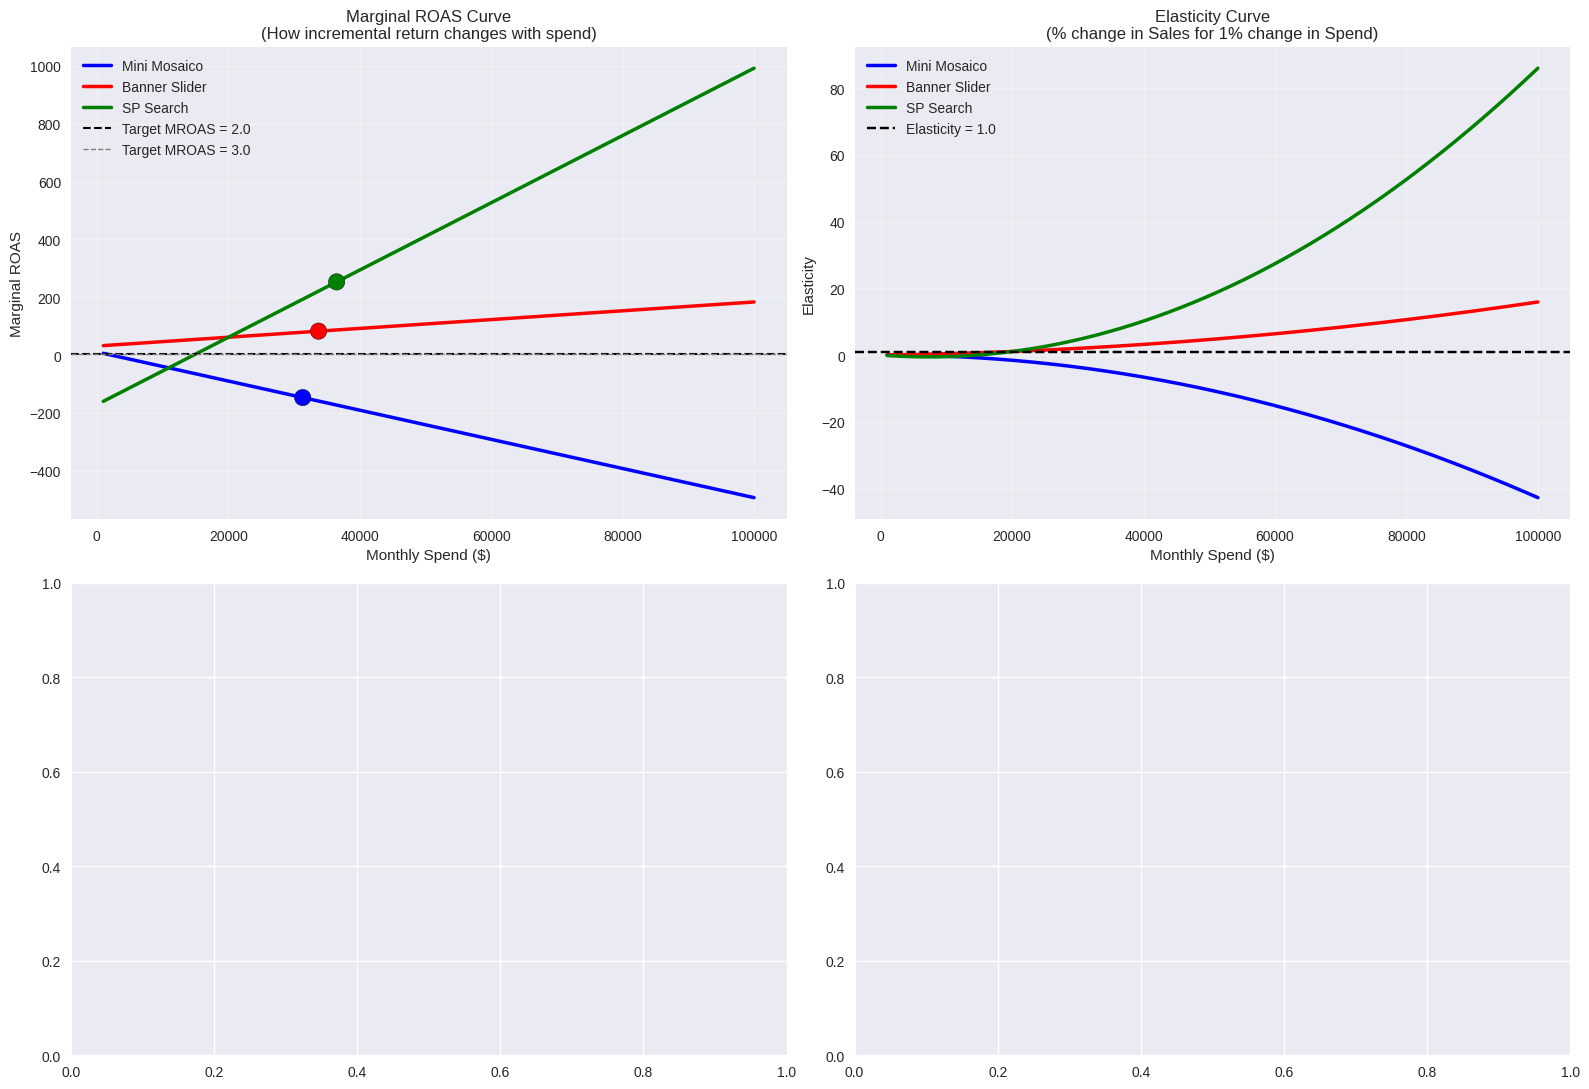

=== Current Situation Analysis ===
Placement       Current Spend Marginal ROAS   Elasticity
-------------------------------------------------------
Mini Mosaico    $31,333       -146.94             -3.99
Banner Slider   $33,750         82.65              2.42
SP Search       $36,500        253.17              8.00


In [16]:
# ==================== FULL PLOTTING CELL (Marginal ROAS + Elasticity) ====================

import matplotlib.pyplot as plt
import numpy as np

# Use coefficients from your fitted model
b_mini1 = model.params['Mini_Spend']
b_mini2 = model.params['Mini_Spend2']
b_banner1 = model.params['Banner_Spend']
b_banner2 = model.params['Banner_Spend2']
b_search1 = model.params['Search_Spend']
b_search2 = model.params['Search_Spend2']

# Define range for plotting
spend_range = np.linspace(1000, 100000, 500)

# Calculate Marginal ROAS
def marginal_roas(spend, beta1, beta2):
    return beta1 + 2 * beta2 * spend

# Calculate Elasticity (for Quadratic model: %change_sales / %change_spend)
def elasticity(spend, beta1, beta2, total_sales_mean):
    # Use np.where to handle the condition for both scalars and arrays
    mroas = marginal_roas(spend, beta1, beta2)
    return np.where(spend == 0, 0, mroas * (spend / total_sales_mean))

# Current average spends
curr_mini = df['Mini_Spend'].mean()
curr_banner = df['Banner_Spend'].mean()
curr_search = df['Search_Spend'].mean()
avg_sales = df['Total_RSV_Sales'].mean()

# ==================== Create Plots ====================
fig, axes = plt.subplots(2, 2, figsize=(16, 11))

# Plot 1: Marginal ROAS Curve
axes[0,0].plot(spend_range, marginal_roas(spend_range, b_mini1, b_mini2),
               label='Mini Mosaico', color='blue', linewidth=2.5)
axes[0,0].plot(spend_range, marginal_roas(spend_range, b_banner1, b_banner2),
               label='Banner Slider', color='red', linewidth=2.5)
axes[0,0].plot(spend_range, marginal_roas(spend_range, b_search1, b_search2),
               label='SP Search', color='green', linewidth=2.5)

axes[0,0].axhline(y=2.0, color='black', linestyle='--', linewidth=1.5, label='Target MROAS = 2.0')
axes[0,0].axhline(y=3.0, color='gray', linestyle='--', linewidth=1, label='Target MROAS = 3.0')

# Mark current spend levels
axes[0,0].scatter([curr_mini, curr_banner, curr_search],
                  [marginal_roas(curr_mini, b_mini1, b_mini2),
                   marginal_roas(curr_banner, b_banner1, b_banner2),
                   marginal_roas(curr_search, b_search1, b_search2)],
                  color=['blue','red','green'], s=140, zorder=5, edgecolors='black')

axes[0,0].set_xlabel('Monthly Spend ($)')
axes[0,0].set_ylabel('Marginal ROAS')
axes[0,0].set_title('Marginal ROAS Curve\n(How incremental return changes with spend)')
axes[0,0].legend()
axes[0,0].grid(True, alpha=0.3)

# Plot 2: Elasticity Curve
axes[0,1].plot(spend_range, elasticity(spend_range, b_mini1, b_mini2, avg_sales),
               label='Mini Mosaico', color='blue', linewidth=2.5)
axes[0,1].plot(spend_range, elasticity(spend_range, b_banner1, b_banner2, avg_sales),
               label='Banner Slider', color='red', linewidth=2.5)
axes[0,1].plot(spend_range, elasticity(spend_range, b_search1, b_search2, avg_sales),
               label='SP Search', color='green', linewidth=2.5)

axes[0,1].axhline(y=1.0, color='black', linestyle='--', label='Elasticity = 1.0')
axes[0,1].set_xlabel('Monthly Spend ($)')
axes[0,1].set_ylabel('Elasticity')
axes[0,1].set_title('Elasticity Curve\n(% change in Sales for 1% change in Spend)')
axes[0,1].legend()
axes[0,1].grid(True, alpha=0.3)

# Plot 3 & 4: You can add Sales Response curves here if needed

plt.tight_layout()
plt.show()

# ==================== Summary Table ====================
print("=== Current Situation Analysis ===")
print(f"{'Placement':<15} {'Current Spend':<12} {'Marginal ROAS':<15} {'Elasticity':<10}")
print("-" * 55)
for name, spend, b1, b2 in [('Mini Mosaico', curr_mini, b_mini1, b_mini2),
                            ('Banner Slider', curr_banner, b_banner1, b_banner2),
                            ('SP Search', curr_search, b_search1, b_search2)]:
    mroas = marginal_roas(spend, b1, b2)
    elas = elasticity(spend, b1, b2, avg_sales)
    # Note: elas here is a 1-element array from np.where, so we take the float value
    print(f"{name:<15} ${spend:,.0f}      {mroas:>8.2f}          {float(elas):>8.2f}")

In [ ]:
#Approach 2--

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
import warnings
warnings.filterwarnings('ignore')

%matplotlib inline
plt.style.use('seaborn-v0_8')

In [ ]:
# ====================== PASTE YOUR REAL DATA HERE ======================
data = {
    'Month': ['2024-06', '2024-07', ...],   # 24 months
    'Total_RSV_Sales': [450000, 480000, ...],
    'Mini_Spend': [12000, 15000, ...],
    'Banner_Spend': [8000, 25000, ...],
    'Search_Spend': [32000, 33000, ...]
}

df = pd.DataFrame(data)
print(df.head())
print("\nData Summary:")
print(df.describe())

In [14]:
# Create squared terms
df['Mini_Spend2'] = df['Mini_Spend'] ** 2
df['Banner_Spend2'] = df['Banner_Spend'] ** 2
df['Search_Spend2'] = df['Search_Spend'] ** 2

# Prepare X and y
X = df[['Mini_Spend', 'Mini_Spend2',
        'Banner_Spend', 'Banner_Spend2',
        'Search_Spend', 'Search_Spend2']]
X = sm.add_constant(X)
y = df['Total_RSV_Sales']

model = sm.OLS(y, X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:        Total_RSV_Sales   R-squared:                       0.997
Model:                            OLS   Adj. R-squared:                  0.996
Method:                 Least Squares   F-statistic:                     1293.
Date:                Thu, 28 May 2026   Prob (F-statistic):           2.40e-22
Time:                        10:40:37   Log-Likelihood:                -275.02
No. Observations:                  24   AIC:                             562.0
Df Residuals:                      18   BIC:                             569.1
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
const            -0.0101      0.009     -1.155

In [17]:
# Extract coefficients
b_mini1 = model.params['Mini_Spend']
b_mini2 = model.params['Mini_Spend2']
b_banner1 = model.params['Banner_Spend']
b_banner2 = model.params['Banner_Spend2']
b_search1 = model.params['Search_Spend']
b_search2 = model.params['Search_Spend2']

def marginal_roas(spend, beta1, beta2):
    return beta1 + 2 * beta2 * spend

curr_mini = df['Mini_Spend'].mean()
curr_banner = df['Banner_Spend'].mean()
curr_search = df['Search_Spend'].mean()

print("=== Current Marginal ROAS ===")
print(f"Mini Mosaico : {marginal_roas(curr_mini, b_mini1, b_mini2):.2f}")
print(f"Banner Slider: {marginal_roas(curr_banner, b_banner1, b_banner2):.2f}")
print(f"SP Search    : {marginal_roas(curr_search, b_search1, b_search2):.2f}")

# Optimal Spend (where Marginal ROAS = 2.0)
def optimal_spend(beta1, beta2, target=2.0):
    if beta2 >= 0:
        return None
    return max(0, (target - beta1) / (2 * beta2))

print("\n=== Recommended Optimal Monthly Spend (MROAS ≈ 2.0) ===")

# Helper to format output safely
def format_output(name, val):
    if val is None:
        print(f"{name:<15} : Not Applicable (Non-diminishing)")
    else:
        print(f"{name:<15} : ${val:,.0f}")

format_output("Mini Mosaico", optimal_spend(b_mini1, b_mini2))
format_output("Banner Slider", optimal_spend(b_banner1, b_banner2))
format_output("SP Search", optimal_spend(b_search1, b_search2))

=== Current Marginal ROAS ===
Mini Mosaico : -146.94
Banner Slider: 82.65
SP Search    : 253.17

=== Recommended Optimal Monthly Spend (MROAS ≈ 2.0) ===
Mini Mosaico    : $1,800
Banner Slider   : Not Applicable (Non-diminishing)
SP Search       : Not Applicable (Non-diminishing)


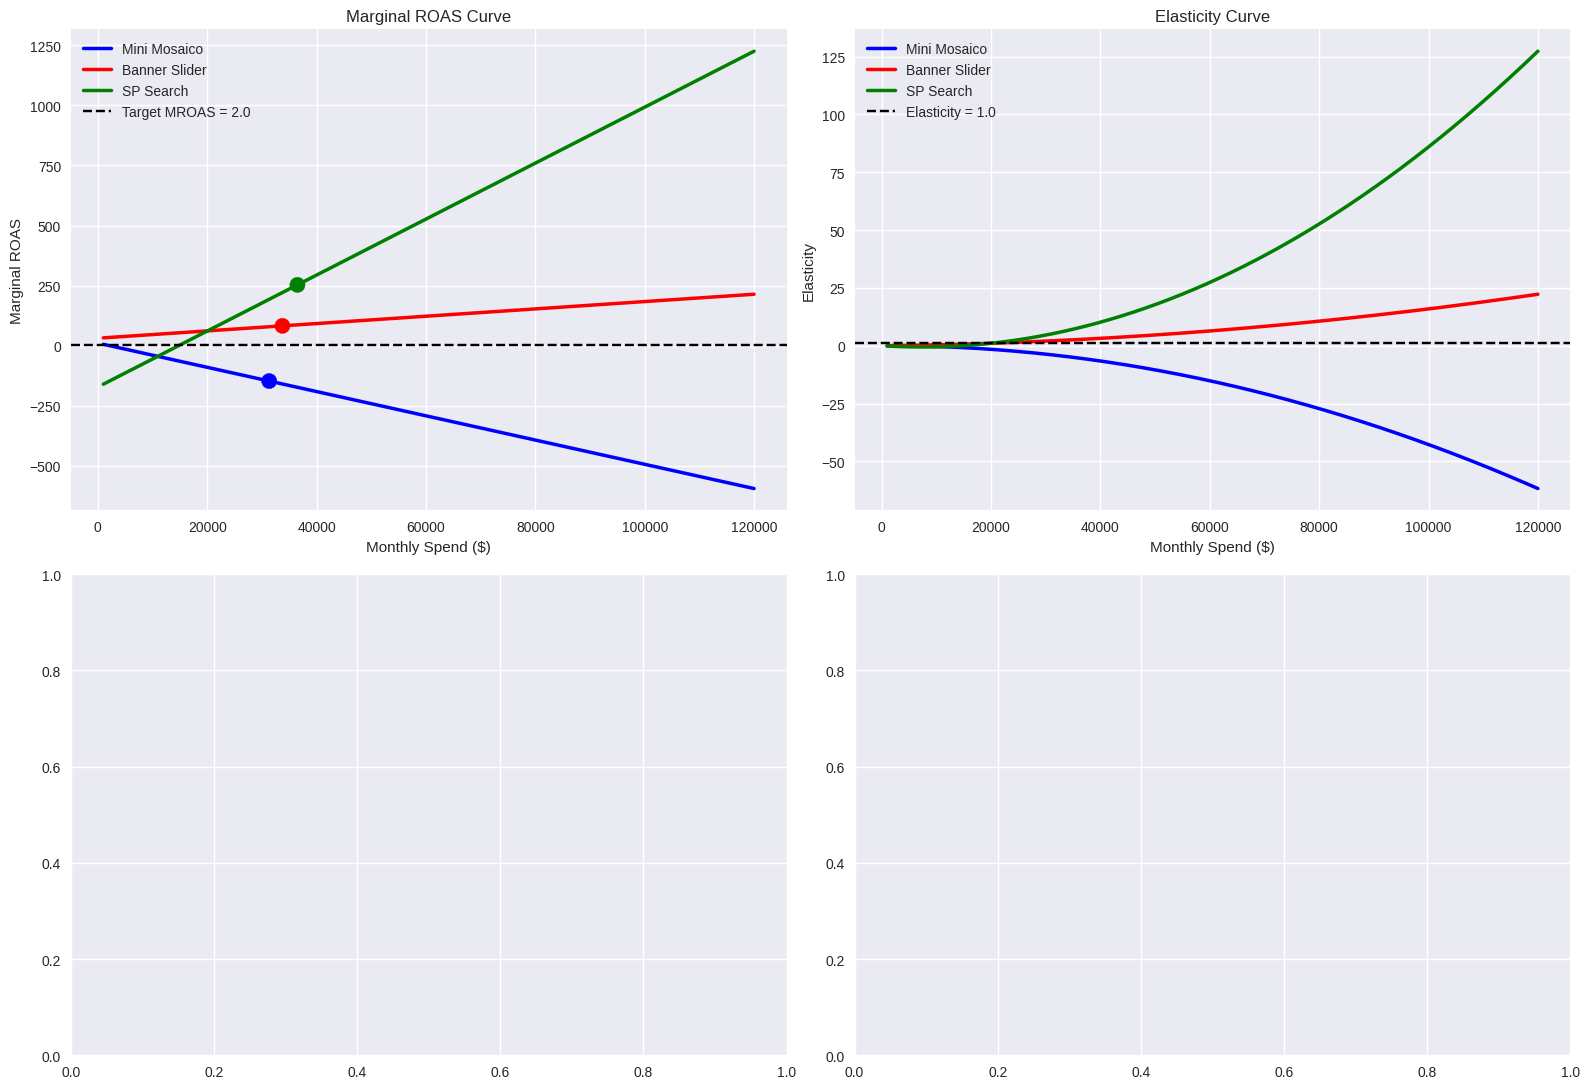

In [18]:
spend_range = np.linspace(1000, 120000, 500)
avg_sales = df['Total_RSV_Sales'].mean()

def elasticity(spend, beta1, beta2, avg_sales):
    # Using np.where to handle both single values and arrays correctly
    mroas = marginal_roas(spend, beta1, beta2)
    return np.where(spend <= 0, 0, mroas * (spend / avg_sales))

fig, axes = plt.subplots(2, 2, figsize=(16, 11))

# Marginal ROAS Plot
axes[0,0].plot(spend_range, marginal_roas(spend_range, b_mini1, b_mini2), label='Mini Mosaico', color='blue', lw=2.5)
axes[0,0].plot(spend_range, marginal_roas(spend_range, b_banner1, b_banner2), label='Banner Slider', color='red', lw=2.5)
axes[0,0].plot(spend_range, marginal_roas(spend_range, b_search1, b_search2), label='SP Search', color='green', lw=2.5)
axes[0,0].axhline(y=2.0, color='black', linestyle='--', label='Target MROAS = 2.0')
axes[0,0].scatter([curr_mini, curr_banner, curr_search],
                  [marginal_roas(curr_mini, b_mini1, b_mini2),
                   marginal_roas(curr_banner, b_banner1, b_banner2),
                   marginal_roas(curr_search, b_search1, b_search2)],
                  color=['blue','red','green'], s=120, zorder=5)

axes[0,0].set_xlabel('Monthly Spend ($)')
axes[0,0].set_ylabel('Marginal ROAS')
axes[0,0].set_title('Marginal ROAS Curve')
axes[0,0].legend()
axes[0,0].grid(True)

# Elasticity Plot
axes[0,1].plot(spend_range, elasticity(spend_range, b_mini1, b_mini2, avg_sales), label='Mini Mosaico', color='blue', lw=2.5)
axes[0,1].plot(spend_range, elasticity(spend_range, b_banner1, b_banner2, avg_sales), label='Banner Slider', color='red', lw=2.5)
axes[0,1].plot(spend_range, elasticity(spend_range, b_search1, b_search2, avg_sales), label='SP Search', color='green', lw=2.5)
axes[0,1].axhline(y=1.0, color='black', linestyle='--', label='Elasticity = 1.0')
axes[0,1].set_xlabel('Monthly Spend ($)')
axes[0,1].set_ylabel('Elasticity')
axes[0,1].set_title('Elasticity Curve')
axes[0,1].legend()
axes[0,1].grid(True)

plt.tight_layout()
plt.show()

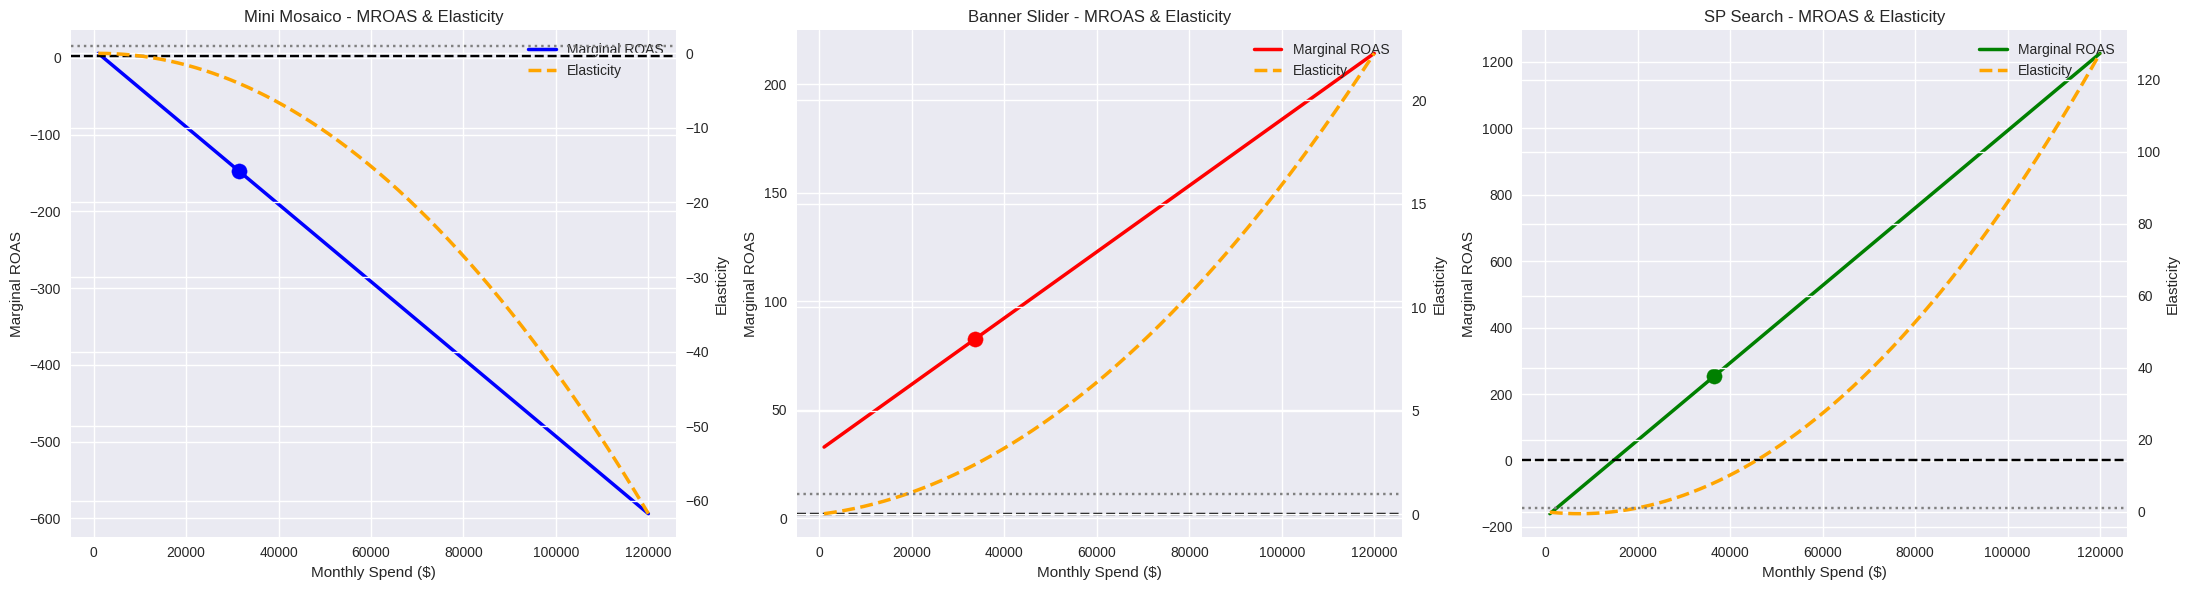

In [19]:
spend_range = np.linspace(1000, 120000, 500)

avg_sales = df['Total_RSV_Sales'].mean()

def elasticity(spend, beta1, beta2, avg_sales):
    mroas = marginal_roas(spend, beta1, beta2)
    return np.where(spend <= 0, 0, mroas * (spend / avg_sales))

# Placement configuration
placements = {
    'Mini Mosaico': {
        'b1': b_mini1,
        'b2': b_mini2,
        'curr_spend': curr_mini,
        'color': 'blue'
    },
    'Banner Slider': {
        'b1': b_banner1,
        'b2': b_banner2,
        'curr_spend': curr_banner,
        'color': 'red'
    },
    'SP Search': {
        'b1': b_search1,
        'b2': b_search2,
        'curr_spend': curr_search,
        'color': 'green'
    }
}

# Create separate graph for each placement
fig, axes = plt.subplots(1, 3, figsize=(22, 6))

for ax, (placement, vals) in zip(axes, placements.items()):

    # Calculate values
    mroas_vals = marginal_roas(
        spend_range,
        vals['b1'],
        vals['b2']
    )

    elasticity_vals = elasticity(
        spend_range,
        vals['b1'],
        vals['b2'],
        avg_sales
    )

    # PRIMARY AXIS → MROAS
    line1 = ax.plot(
        spend_range,
        mroas_vals,
        color=vals['color'],
        lw=2.5,
        label='Marginal ROAS'
    )

    ax.axhline(
        y=2.0,
        color='black',
        linestyle='--',
        label='Target MROAS = 2'
    )

    # Current spend point
    ax.scatter(
        vals['curr_spend'],
        marginal_roas(
            vals['curr_spend'],
            vals['b1'],
            vals['b2']
        ),
        color=vals['color'],
        s=120,
        zorder=5
    )

    ax.set_xlabel('Monthly Spend ($)')
    ax.set_ylabel('Marginal ROAS')
    ax.grid(True)

    # SECONDARY AXIS → Elasticity
    ax2 = ax.twinx()

    line2 = ax2.plot(
        spend_range,
        elasticity_vals,
        color='orange',
        lw=2.5,
        linestyle='--',
        label='Elasticity'
    )

    ax2.axhline(
        y=1.0,
        color='gray',
        linestyle=':'
    )

    ax2.set_ylabel('Elasticity')

    # Combined legend
    lines = line1 + line2
    labels = [l.get_label() for l in lines]

    ax.legend(lines, labels, loc='upper right')

    # Title
    ax.set_title(f'{placement} - MROAS & Elasticity')

plt.tight_layout()
plt.show()